<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 12px; text-align: center; color: white; font-family: 'Segoe UI', sans-serif;">
    <h1 style="font-size: 2.2em; margin-bottom: 10px; letter-spacing: 2px;">
        🛰️ Classification de Drones par Signal RF
    </h1>
    <h2 style="font-size: 1.3em; font-weight: 300; color: #a8d8ea; margin-bottom: 20px;">
        Réseau de Neurones Convolutif (CNN) — Dataset DroneRF
    </h2>
    <hr style="border: 1px solid #a8d8ea; width: 60%; margin: 20px auto;">
</div>


<a id="section1"></a>

## 1-  Contexte & Architecture des Classes

### Présentation du Dataset DroneRF

Le dataset **DroneRF** contient des signaux RF (Radio Fréquence) capturés lors de vols de drones dans différentes configurations.  
Chaque enregistrement est segmenté en plusieurs fenêtres temporelles, converties en **spectrogrammes PNG**.

Chaque classe est identifiée par un **BUI** (*Binary Unique Identifier*) : un code binaire de 5 bits qui encode le type de drone et son mode de vol.

### Tableau des 13 Classes

| BUI   | Classe | Drone      | Mode de vol            |
|-------|--------|------------|------------------------|
| 00000 | 0      | —          | Background (pas de drone) |
| 10000 | 1      | Bebop      | Mode 1 — Connected     |
| 10001 | 2      | Bebop      | Mode 2 — Hovering      |
| 10010 | 3      | Bebop      | Mode 3 — Flying        |
| 10011 | 4      | Bebop      | Mode 4 — Flying + Video|
| 10100 | 5      | AR Drone   | Mode 1 — Connected     |
| 10101 | 6      | AR Drone   | Mode 2 — Hovering      |
| 10110 | 7      | AR Drone   | Mode 3 — Flying        |
| 10111 | 8      | AR Drone   | Mode 4 — Flying + Video|
| 11000 | 9      | Phantom    | Mode 1 — Connected     |
| 11001 | 10     | Phantom    | Mode 2 — Hovering      |
| 11010 | 11     | Phantom    | Mode 3 — Flying        |
| 11011 | 12     | Phantom    | Mode 4 — Flying + Video|

> **Lecture du BUI** : Le bit de poids fort identifie la présence d'un drone (1) ou son absence (0).  
> Les 4 bits restants encodent le type de drone et le mode de vol.


---

<a id="section2"></a>

## 2 — Imports & Configuration

On importe ici l'ensemble des bibliothèques nécessaires au projet, puis on configure le dispositif de calcul (CPU ou GPU).


In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPORTS
# ══════════════════════════════════════════════════════════════════════════════

# ── Framework Deep Learning ──────────────────────────────────────────────────
import torch                                    # PyTorch : framework principal
import torch.nn as nn                           # Modules de construction du réseau (couches, loss…)
import torch.nn.functional as F                 # Fonctions : relu, softmax, etc.
import torch.optim as optim                     # Algorithmes d'optimisation : Adam, SGD…
from torch.utils.data import Dataset, DataLoader, random_split, Subset
#   Dataset      : classe de base pour un dataset personnalisé
#   DataLoader   : charge les données par lots (batches)
#   random_split : divise un dataset en sous-ensembles
#   Subset       : crée un sous-dataset à partir d'une liste d'indices

# ── Vision & Images ──────────────────────────────────────────────────────────
from torchvision import transforms              # Transformations d'images (resize, normalize…)
from PIL import Image                           # Lecture des fichiers PNG

# ── Utilitaires Python ───────────────────────────────────────────────────────
import os                                       # Interaction avec le système de fichiers
import re                                       # Expressions régulières (parsing des noms de fichiers)
import random                                   # Mélange aléatoire reproductible
from collections import Counter                 # Comptage rapide par classe
from tqdm import tqdm                           # Barre de progression

# ── Calcul & Visualisation ───────────────────────────────────────────────────
import numpy as np                              # Calcul numérique vectorisé
import matplotlib.pyplot as plt                 # Tracé de graphiques
from sklearn.decomposition import PCA           # Réduction de dimension linéaire
from sklearn.manifold import TSNE               # Réduction non-linéaire (t-SNE)

print(" Toutes les bibliothèques ont été importées avec succès.")

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION DU DISPOSITIF DE CALCUL
# ══════════════════════════════════════════════════════════════════════════════

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n  Dispositif utilisé : {device}")

if device.type == 'cuda':
    # torch.backends.cudnn.benchmark = True :
    #   Active la sélection automatique de l'algorithme de convolution le plus rapide.
    #   Recommandé uniquement quand la taille d'entrée est fixe (128×128 ici).
    torch.backends.cudnn.benchmark = True
    print(f"   GPU détecté : {torch.cuda.get_device_name(0)}")
    print(f"   Mémoire GPU disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("     Aucun GPU détecté — le calcul se fera sur CPU (plus lent).")


 Toutes les bibliothèques ont été importées avec succès.

  Dispositif utilisé : cuda
   GPU détecté : NVIDIA GeForce RTX 2050
   Mémoire GPU disponible : 4.3 GB


---

<a id="section3"></a>

## 3 — Mapping des Classes & Dataset Personnalisé

### Pourquoi un Dataset personnalisé ?

La classe standard `torchvision.datasets.ImageFolder` attend une **arborescence de dossiers** (un dossier par classe).  
Ici, toutes les images coexistent dans les mêmes répertoires, et la classe est encodée dans le **nom du fichier** via le BUI binaire.

> **Exemple :** `Phantom_M1_11000L_9_Seg94.png` → BUI `11000` → Classe 9 (Phantom Mode 1)

Un dataset personnalisé `DroneRFDataset` est donc nécessaire pour :
- Extraire le BUI depuis le nom de fichier à l'aide d'une expression régulière
- Gérer les deux bandes fréquentielles (H et L) comme exemples indépendants
- Grouper les segments par enregistrement source pour le split anti-leakage


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# MAPPING BUI → NUMÉRO DE CLASSE
# ══════════════════════════════════════════════════════════════════════════════

# BUI = Binary Unique Identifier
# Code binaire de 5 bits attribué à chaque combinaison (type de drone, mode de vol)
# défini dans la documentation officielle du dataset DroneRF.

BUI_TO_CLASS = {
    "00000": 0,    # Background       — pas de drone actif
    "10000": 1,    # Bebop  — Mode 1 : Connected
    "10001": 2,    # Bebop  — Mode 2 : Hovering
    "10010": 3,    # Bebop  — Mode 3 : Flying
    "10011": 4,    # Bebop  — Mode 4 : Flying + Video
    "10100": 5,    # AR Drone — Mode 1 : Connected
    "10101": 6,    # AR Drone — Mode 2 : Hovering
    "10110": 7,    # AR Drone — Mode 3 : Flying
    "10111": 8,    # AR Drone — Mode 4 : Flying + Video
    "11000": 9,    # Phantom — Mode 1 : Connected
    "11001": 10,   # Phantom — Mode 2 : Hovering
    "11010": 11,   # Phantom — Mode 3 : Flying
    "11011": 12,   # Phantom — Mode 4 : Flying + Video
}

# Noms lisibles pour les axes de la matrice de confusion et les légendes
CLASS_NAMES = [
    "Background",
    "Bebop M1", "Bebop M2",   "Bebop M3",   "Bebop M4",
    "AR M1",    "AR M2",      "AR M3",       "AR M4",
    "Phantom M1","Phantom M2","Phantom M3",  "Phantom M4",
]

NB_CLASSES = len(BUI_TO_CLASS)  # 13 classes au total
print(f" Nombre de classes : {NB_CLASSES}")
print(f"   Classes : {CLASS_NAMES}")


# ══════════════════════════════════════════════════════════════════════════════
# FONCTIONS UTILITAIRES : PARSING DES NOMS DE FICHIERS
# ══════════════════════════════════════════════════════════════════════════════

def extraire_bui(filename):
    """
    Extrait le code BUI (5 chiffres binaires) depuis le nom du fichier.

    Méthode : recherche la première séquence de 5 caractères {0, 1}
    à l'aide de l'expression régulière r'[01]{5}'.

    Paramètres
    ----------
    filename : str
        Nom du fichier image, ex. 'Phantom_M1_11000L_9_Seg94.png'

    Retourne
    --------
    str  : le BUI extrait, ex. '11000'
    None : si aucune séquence de 5 bits n'est trouvée
    """
    match = re.search(r'[01]{5}', filename)
    return match.group() if match else None


def extraire_recording_id(filename):
    """
    Extrait l'identifiant unique d'un enregistrement SOURCE,
    en supprimant le suffixe de segment '_SegX.png'.

    Utilité : éviter le data leakage lors du split train/test.
    Tous les segments issus du même enregistrement doivent appartenir
    exclusivement soit au train, soit au test.

    Paramètres
    ----------
    filename : str
        Nom du fichier, ex. 'Phantom_M1_11000L_9_Seg94.png'

    Retourne
    --------
    str : identifiant de l'enregistrement, ex. 'Phantom_M1_11000L_9'
    """
    return re.sub(r'_Seg\d+\.png$', '', filename, flags=re.IGNORECASE)


# ══════════════════════════════════════════════════════════════════════════════
# DATASET PERSONNALISÉ : DroneRFDataset
# ══════════════════════════════════════════════════════════════════════════════

class DroneRFDataset(Dataset):
    """
    Dataset PyTorch personnalisé pour le projet DroneRF.

    Différences avec ImageFolder (standard torchvision) :
    ┌─────────────────────────────────────────────────────────────┐
    │  ImageFolder          DroneRFDataset (ce code)              │
    ├─────────────────────────────────────────────────────────────┤
    │  1 dossier/classe     Dossiers mélangés (H et L)            │
    │  Classe = nom dossier Classe = BUI dans le nom de fichier   │
    │  Pas de leakage natif Split manuel par enregistrement        │
    └─────────────────────────────────────────────────────────────┘

    Attributs
    ---------
    samples   : list of (chemin_image, numéro_classe)
    transform : transformations torchvision à appliquer
    """

    def __init__(self, folders, transform=None):
        """
        Paramètres
        ----------
        folders   : list[str] — chemins vers les dossiers contenant les PNG
        transform : torchvision.transforms — pipeline de transformations
        """
        self.transform = transform
        self.samples = []          # Stocke les paires (chemin, classe)

        for folder in folders:
            if not os.path.exists(folder):
                print(f"  Dossier introuvable : {folder}")
                continue

            for filename in os.listdir(folder):
                if not filename.lower().endswith(".png"):
                    continue    # Ignore tous les fichiers non-PNG

                bui = extraire_bui(filename)

                if bui is None:
                    print(f"  BUI manquant dans le nom : {filename}")
                    continue
                if bui not in BUI_TO_CLASS:
                    print(f"  BUI '{bui}' non reconnu dans : {filename}")
                    continue

                classe = BUI_TO_CLASS[bui]
                chemin = os.path.join(folder, filename)
                self.samples.append((chemin, classe))

        # ── Résumé du chargement ──────────────────────────────────────────
        comptage = Counter(c for _, c in self.samples)
        print(f"\n {len(self.samples):,} images chargées au total")
        print("\n   Répartition par classe :")
        print(f"   {'Classe':>7} | {'Nom':16} | {'Images':>8}")
        print(f"   {'─'*7}─┼─{'─'*16}─┼─{'─'*8}")
        for i, nom in enumerate(CLASS_NAMES):
            print(f"   {i:>7} | {nom:16} | {comptage.get(i, 0):>8,}")

    def __len__(self):
        """Nombre total d'images dans le dataset."""
        return len(self.samples)

    def __getitem__(self, idx):
        """
        Retourne l'image et son label pour un index donné.

        Retourne
        --------
        image  : Tensor — image transformée (C, H, W)
        classe : int    — numéro de classe (0 à 12)
        """
        chemin, classe = self.samples[idx]
        image = Image.open(chemin).convert("RGB")   # Chargement en mode RGB (3 canaux)
        if self.transform:
            image = self.transform(image)
        return image, classe


 Nombre de classes : 13
   Classes : ['Background', 'Bebop M1', 'Bebop M2', 'Bebop M3', 'Bebop M4', 'AR M1', 'AR M2', 'AR M3', 'AR M4', 'Phantom M1', 'Phantom M2', 'Phantom M3', 'Phantom M4']


---

<a id="section4"></a>

## 4 — Chargement des Données & Split Anti-Leakage

### Problème du Data Leakage dans les Données Temporelles

Un enregistrement de signal RF est découpé en **N segments** (typiquement ~95 segments par enregistrement).  
Ces segments sont **fortement corrélés** car ils proviennent du même signal source.

**Problème :** Un split aléatoire classique placerait les segments 0–80 dans le train et 81–94 dans le test,  
permettant au modèle d'"apprendre" le signal test → **precision artificiellement gonflée**.

**Solution adoptée :** Split **par enregistrement entier**, garantissant qu'aucun segment  
du même enregistrement ne se retrouve simultanément dans le train et le test.

```
Enregistrement A : [Seg0, Seg1, ..., Seg94] → 100% TRAIN
Enregistrement B : [Seg0, Seg1, ..., Seg94] → 100% TEST
```


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# TRANSFORMATIONS DES IMAGES
# ══════════════════════════════════════════════════════════════════════════════

data_transforms = transforms.Compose([
    transforms.Resize((128, 128)),      # Redimensionne à 128×128 pixels
    transforms.ToTensor(),              # Convertit PIL Image → tenseur Float [0.0, 1.0]
    transforms.Normalize([0.5], [0.5])  # Normalise vers [-1.0, +1.0] : (x - 0.5) / 0.5
])

print("Pipeline de transformations défini :")
print("   Resize(128×128) → ToTensor → Normalize(mean=0.5, std=0.5)")


# ══════════════════════════════════════════════════════════════════════════════
# CHEMINS VERS LES DOSSIERS DE DONNÉES
# ══════════════════════════════════════════════════════════════════════════════


# Chaque dossier contient directement les fichiers PNG (pas de sous-dossiers par classe)

FOLDERS = [
   r"C:\Users\user\Downloads\Background\Background",  # Bruit de fond (pas de drone)
   r"C:\Users\user\Downloads\Bebop\Bebop",                    # Drone Bebop
   r"C:\Users\user\Downloads\AR_Drone\AR_Drone",  # Drone AR
   r"C:\Users\user\Downloads\Phantom\Phantom"                  # Drone Phantom
]


# ══════════════════════════════════════════════════════════════════════════════
# CHARGEMENT DU DATASET COMPLET
# ══════════════════════════════════════════════════════════════════════════════

full_dataset = DroneRFDataset(FOLDERS, transform=data_transforms)


# ══════════════════════════════════════════════════════════════════════════════
# SPLIT PAR ENREGISTREMENT — Stratégie Anti-Leakage
# ══════════════════════════════════════════════════════════════════════════════

# ── Étape 1 : Grouper les indices par enregistrement source ───────────────────
# Un "enregistrement" = tous les segments d'un même fichier source
# Ex. : 'Phantom_M1_11000L_9' regroupe Seg0, Seg1, …, Seg94

recording_to_indices = {}   # dict : recording_id (str) → liste d'indices (int)

for idx, (chemin, _) in enumerate(full_dataset.samples):
    filename  = os.path.basename(chemin)         # 'Phantom_M1_11000L_9_Seg94.png'
    rec_id    = extraire_recording_id(filename)  # 'Phantom_M1_11000L_9'
    recording_to_indices.setdefault(rec_id, []).append(idx)

nb_rec = len(recording_to_indices)
print(f"\n Statistiques des enregistrements :")
print(f"   Enregistrements uniques       : {nb_rec:,}")
print(f"   Segments moyens / enreg.      : {len(full_dataset) / nb_rec:.1f}")


# ── Étape 2 : Mélanger et diviser les enregistrements (90% / 10%) ────────────
all_recordings = list(recording_to_indices.keys())
random.seed(42)               # Graine fixe pour la reproductibilité
random.shuffle(all_recordings)

split_point      = int(0.9 * len(all_recordings))
train_recordings = all_recordings[:split_point]   # 90 % des enregistrements → train
test_recordings  = all_recordings[split_point:]   # 10 % des enregistrements → test


# ── Étape 3 : Récupérer les indices de segments associés ─────────────────────
train_indices = [i for rec in train_recordings for i in recording_to_indices[rec]]
test_indices  = [i for rec in test_recordings  for i in recording_to_indices[rec]]

print(f"\n Split anti-leakage (90/10) :")
print(f"   Enregistrements train : {len(train_recordings):>5,}  →  {len(train_indices):>7,} segments")
print(f"   Enregistrements test  : {len(test_recordings):>5,}  →  {len(test_indices):>7,} segments")
print(f"   Ratio réel train/test : {len(train_indices)/len(full_dataset)*100:.1f}% / "
      f"{len(test_indices)/len(full_dataset)*100:.1f}%")


# ── Étape 4 : Créer les sous-datasets ────────────────────────────────────────
train_data = Subset(full_dataset, train_indices)
test_data  = Subset(full_dataset, test_indices)


# ══════════════════════════════════════════════════════════════════════════════
# CRÉATION DES DATALOADERS
# ══════════════════════════════════════════════════════════════════════════════

# DataLoader TRAIN
# ─────────────────
# batch_size=64   : 64 images envoyées au GPU à la fois (compromis vitesse/mémoire)
# shuffle=True    : mélange les batches à chaque époque pour améliorer la convergence
# num_workers=0   : 0 = chargement dans le processus principal (compatible Windows/macOS)
# pin_memory=True : alloue la mémoire en mode paginé → transfert CPU→GPU plus rapide
train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

# DataLoader TEST
# ────────────────
# batch_size=256  : batch plus grand pour l'évaluation (pas de gradient à stocker)
# shuffle=False   : ordre fixe pour la reproductibilité des métriques
test_loader = DataLoader(
    test_data,
    batch_size=256,
    shuffle=False
)

print(f"\n Pipeline de données prêt !")
print(f"   Total images               : {len(full_dataset):>8,}")
print(f"   Images d'entraînement      : {len(train_data):>8,}")
print(f"   Images de test             : {len(test_data):>8,}")
print(f"   Batches par époque (train) : {len(train_loader):>8,}")
print(f"   Batches par époque (test)  : {len(test_loader):>8,}")


Pipeline de transformations défini :
   Resize(128×128) → ToTensor → Normalize(mean=0.5, std=0.5)

 454,000 images chargées au total

   Répartition par classe :
    Classe | Nom              |   Images
   ────────┼──────────────────┼─────────
         0 | Background       |   82,000
         1 | Bebop M1         |   42,000
         2 | Bebop M2         |   42,000
         3 | Bebop M3         |   42,000
         4 | Bebop M4         |   42,000
         5 | AR M1            |   42,000
         6 | AR M2            |   42,000
         7 | AR M3            |   42,000
         8 | AR M4            |   36,000
         9 | Phantom M1       |   42,000
        10 | Phantom M2       |        0
        11 | Phantom M3       |        0
        12 | Phantom M4       |        0

 Statistiques des enregistrements :
   Enregistrements uniques       : 454
   Segments moyens / enreg.      : 1000.0

 Split anti-leakage (90/10) :
   Enregistrements train :   408  →  408,000 segments
   Enregistrements t

---

<a id="section5"></a>

## 5 — Architecture du Modèle CNN

Le modèle est un **CNN à 3 blocs convolutifs** suivi de 2 couches entièrement connectées.

### Flux de données à travers le réseau

```
Entrée        (N, 3, 128, 128)   ← batch de N images RGB 128×128
   │
   ├─ Conv2d(3→32, 3×3) + ReLU + MaxPool(2×2)   → (N, 32, 64, 64)
   ├─ Conv2d(32→64, 3×3) + ReLU + MaxPool(2×2)  → (N, 64, 32, 32)
   ├─ Conv2d(64→128, 3×3) + ReLU + MaxPool(2×2) → (N, 128, 16, 16)
   │
   ├─ Flatten                                    → (N, 32768)
   ├─ Linear(32768→256) + ReLU                  → (N, 256)
   └─ Linear(256→13)                            → (N, 13)  ← logits bruts
```




In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# DÉFINITION DE L'ARCHITECTURE CNN
# ══════════════════════════════════════════════════════════════════════════════

class DroneCNN(nn.Module):
    """
    Réseau de Neurones Convolutif pour la classification de drones RF.

    Architecture — 3 blocs convolutifs + 2 couches FC :

        Input (3 × 128 × 128)
          → [Conv2d(3→32)   + ReLU + MaxPool] → (32 × 64 × 64)
          → [Conv2d(32→64)  + ReLU + MaxPool] → (64 × 32 × 32)
          → [Conv2d(64→128) + ReLU + MaxPool] → (128 × 16 × 16)
          → Flatten                           → (32 768,)
          → [Linear(32768→256) + ReLU]        → (256,)
          → [Linear(256→13)]                  → (13,)  ← logits

    Paramètres
    ----------
    nb_classes : int — nombre de classes à prédire (défaut : 13)
    """

    def __init__(self, nb_classes: int = 13):
        super(DroneCNN, self).__init__()

        # ── Bloc convolutif 1 ───────────────────────────────────────────────
        # Détecte les caractéristiques bas-niveau : contours, textures
        # in_channels=3  : image RGB (R, G, B)
        # out_channels=32: 32 filtres appris
        # kernel_size=3  : filtre 3×3
        # padding=1      : zero-padding pour conserver la taille spatiale après conv
        self.conv1 = nn.Conv2d(in_channels=3,  out_channels=32,  kernel_size=3, padding=1)

        # ── Bloc convolutif 2 ───────────────────────────────────────────────
        # Détecte des motifs de niveau intermédiaire
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64,  kernel_size=3, padding=1)

        # ── Bloc convolutif 3 ───────────────────────────────────────────────
        # Détecte des caractéristiques complexes, propres à chaque classe
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        # MaxPool commun : kernel 2×2, stride 2
        # → divise la résolution spatiale par 2 à chaque application
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # ── Couches entièrement connectées ──────────────────────────────────
        # Après 3 applications de MaxPool sur une image 128×128 :
        #   128 → 64 → 32 → 16  (par dimension)
        # Volume de feature maps aplati : 128 filtres × 16 × 16 = 32 768 valeurs
        self.fc1 = nn.Linear(in_features=128 * 16 * 16, out_features=256)  # 32768 → 256
        self.fc2 = nn.Linear(in_features=256,           out_features=nb_classes)  # 256 → 13

        # Pas de Dropout dans cette version (cf. justification dans la section 5)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Propagation avant (inference).

        Paramètres
        ----------
        x : Tensor de forme (N, 3, 128, 128) — batch de N images

        Retourne
        --------
        Tensor de forme (N, 13) — scores (logits) non normalisés pour chaque classe
        """

        # Étage 1 : convolution + activation + sous-échantillonnage
        # (N, 3, 128, 128) → (N, 32, 64, 64)
        x = self.pool(F.relu(self.conv1(x)))

        # Étage 2 : (N, 32, 64, 64) → (N, 64, 32, 32)
        x = self.pool(F.relu(self.conv2(x)))

        # Étage 3 : (N, 64, 32, 32) → (N, 128, 16, 16)
        x = self.pool(F.relu(self.conv3(x)))

        # Aplatissement du volume 3D en vecteur 1D
        # (N, 128, 16, 16) → (N, 32768)
        x = x.view(x.size(0), -1)  # x.size(0) = N (taille du batch)

        # Couche FC1 + ReLU : 32768 → 256
        x = F.relu(self.fc1(x))

        # Couche FC2 (sortie) : 256 → 13 logits bruts
        return self.fc2(x)


# ══════════════════════════════════════════════════════════════════════════════
# INSTANCIATION ET VÉRIFICATION DU MODÈLE
# ══════════════════════════════════════════════════════════════════════════════

model = DroneCNN(nb_classes=NB_CLASSES).to(device)

# ── Résumé de l'architecture ─────────────────────────────────────────────────
print("=" * 60)
print("ARCHITECTURE DU MODÈLE DroneCNN")
print("=" * 60)
print(model)

# ── Comptage des paramètres entraînables ─────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters() if p.requires_grad)
params_par_couche = {
    name: p.numel()
    for name, p in model.named_parameters() if p.requires_grad
}

print(f"\n{'─'*60}")
print("PARAMÈTRES ENTRAÎNABLES PAR COUCHE")
print(f"{'─'*60}")
for nom, nb in params_par_couche.items():
    print(f"  {nom:30s} : {nb:>10,} paramètres")
print(f"{'─'*60}")
print(f"  {'TOTAL':30s} : {total_params:>10,} paramètres")
print(f"{'─'*60}")

# ── Vérification des dimensions clés ─────────────────────────────────────────
print(f"\n Vérifications :")
print(f"   fc1.in_features   = {model.fc1.in_features}  (attendu : 32768 = 128×16×16)")
print(f"   fc2.out_features  = {model.fc2.out_features}   (attendu : 13 classes)")
print(f"   Dropout           = absent ")
print(f"   Dispositif        = {next(model.parameters()).device}")


ARCHITECTURE DU MODÈLE DroneCNN
DroneCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=13, bias=True)
)

────────────────────────────────────────────────────────────
PARAMÈTRES ENTRAÎNABLES PAR COUCHE
────────────────────────────────────────────────────────────
  conv1.weight                   :        864 paramètres
  conv1.bias                     :         32 paramètres
  conv2.weight                   :     18,432 paramètres
  conv2.bias                     :         64 paramètres
  conv3.weight                   :     73,728 paramètres
  conv3.bias                     :        128 paramètres
  fc1.weight   

---

<a id="section6"></a>

##  6 — Visualisation t-SNE Avant Entraînement

### Objectif

Nous appliquons ici **t-SNE** (*t-Distributed Stochastic Neighbor Embedding*) sur les **pixels bruts**  
des images (sans passer par le CNN) afin de visualiser la **séparabilité intrinsèque** des classes.

**Hypothèse attendue :** Les 13 classes sont fortement mélangées dans l'espace des pixels bruts.  
Cela justifiera l'utilisation d'un CNN pour extraire des représentations plus discriminantes.

### Pipeline de réduction dimensionnelle

```
Images brutes (N, 3, 128, 128)
   │
   ├─ Flatten       → (N, 49 152)  ← valeurs des pixels
   ├─ PCA(50 dim.)  → (N, 50)      ← pré-réduction rapide (linéaire)
   └─ t-SNE(2 dim.) → (N, 2)       ← réduction non-linéaire pour visualisation
```

> **Pourquoi PCA avant t-SNE ?**  
> t-SNE a une complexité en O(N²) sur la dimension d'entrée.  
> Réduire de 49 152 → 50 dimensions via PCA rend le calcul t-SNE feasible  
> tout en préservant l'essentiel de la variance.


 Extraction des pixels bruts depuis le jeu de test...

 Extraction terminée
   Nombre d'images : 2,000
   Dimension brute : 49,152 valeurs par image (3 × 128 × 128)

⏳ PCA en cours (49 152 → 50 composantes)...
 PCA terminée
   Variance expliquée par les 50 premières composantes : 95.3%

⏳ t-SNE en cours (50 → 2 dimensions)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.002s...
[t-SNE] Computed neighbors for 2000 samples in 4.672s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 52.671974
[t-SNE] KL divergence after 1000 iterations: 0.749130
 t-SNE terminé !


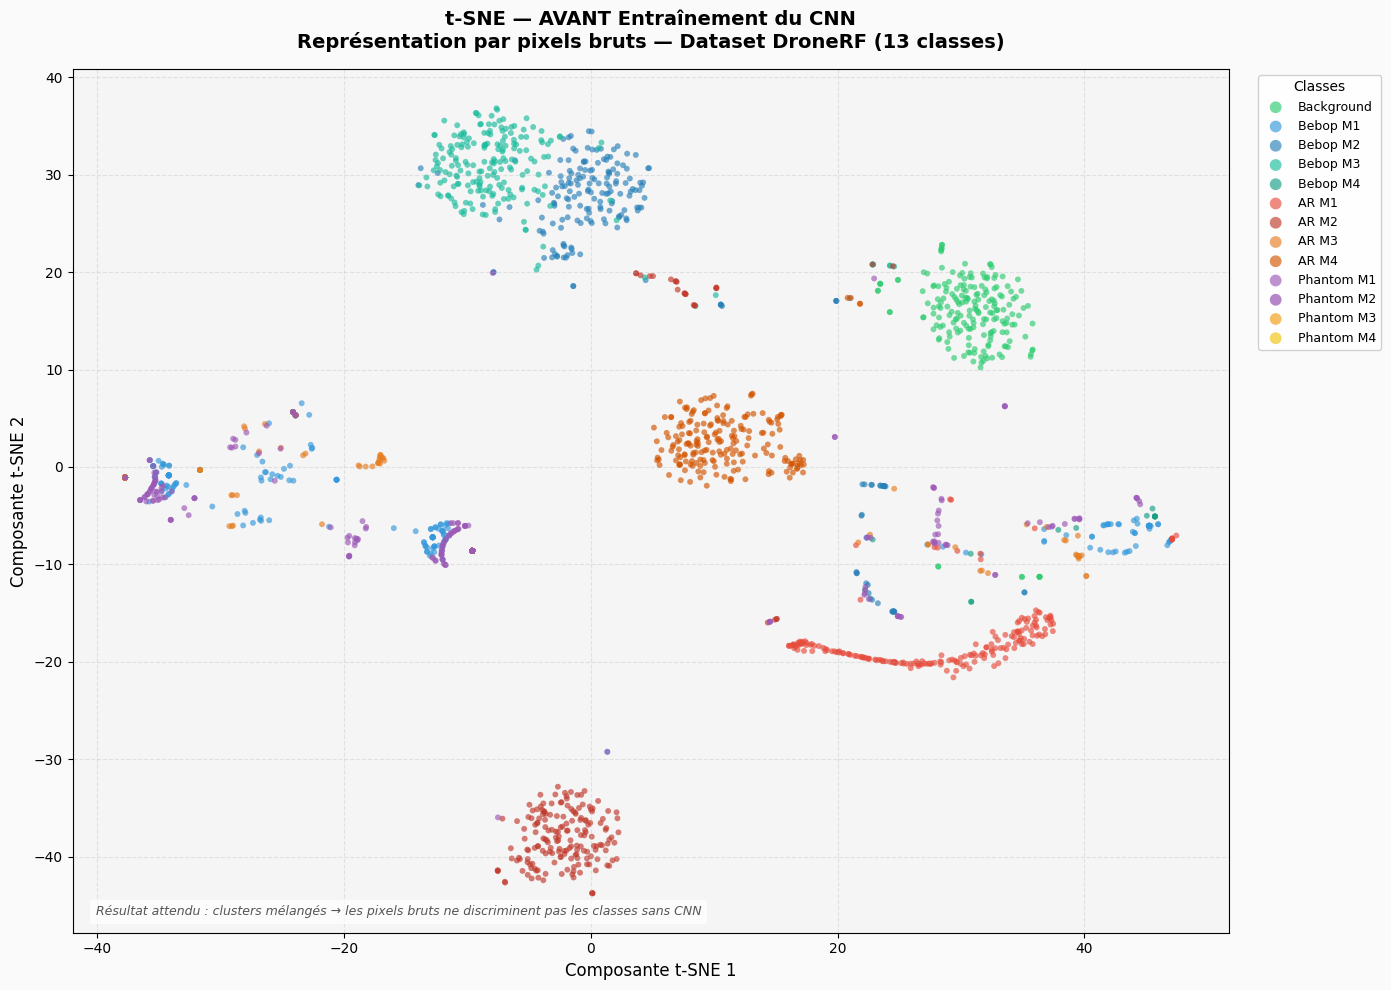


 Figure sauvegardée : tsne_avant_entrainement.png

 Interprétation :
   → Si les clusters sont mélangés : les features brutes sont insuffisantes.
   → Le CNN devra apprendre des représentations plus discriminantes.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# EXTRACTION DES FEATURES BRUTES (PIXELS APLATIS)
# ══════════════════════════════════════════════════════════════════════════════

NB_PAR_CLASSE = 200   # Images échantillonnées par classe (200 × 13 = 2 600 total)
                       # Compromis entre représentativité et temps de calcul

images_list = []
labels_list = []
comptage    = {i: 0 for i in range(NB_CLASSES)}

print(" Extraction des pixels bruts depuis le jeu de test...")

for images, labels in test_loader:
    for img, lbl in zip(images, labels):
        classe = int(lbl)
        if comptage[classe] < NB_PAR_CLASSE:
            # Aplatissement : tenseur (3, 128, 128) → vecteur (49 152,)
            images_list.append(img.numpy().flatten())
            labels_list.append(classe)
            comptage[classe] += 1

    # Condition d'arrêt : toutes les classes ont atteint le quota
    if all(v >= NB_PAR_CLASSE for v in comptage.values()):
        break

X = np.array(images_list)   # Forme : (2600, 49152)
y = np.array(labels_list)   # Forme : (2600,)

print(f"\n Extraction terminée")
print(f"   Nombre d'images : {len(X):,}")
print(f"   Dimension brute : {X.shape[1]:,} valeurs par image (3 × 128 × 128)")


# ══════════════════════════════════════════════════════════════════════════════
# ÉTAPE 1 : PCA — Pré-réduction de dimension (49 152 → 50)
# ══════════════════════════════════════════════════════════════════════════════

print("\n⏳ PCA en cours (49 152 → 50 composantes)...")

pca   = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)

variance_cumulee = pca.explained_variance_ratio_.sum() * 100
print(f" PCA terminée")
print(f"   Variance expliquée par les 50 premières composantes : {variance_cumulee:.1f}%")


# ══════════════════════════════════════════════════════════════════════════════
# ÉTAPE 2 : t-SNE — Réduction non-linéaire (50 → 2)
# ══════════════════════════════════════════════════════════════════════════════

# Hyperparamètres t-SNE :
# perplexity=30 : nombre "effectif" de voisins proches considérés (~5-50 typique)
# max_iter=1000 : nombre d'itérations d'optimisation
# random_state  : graine fixe pour la reproductibilité exacte

print("\n⏳ t-SNE en cours (50 → 2 dimensions)...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42,
    verbose=1
)
X_2d = tsne.fit_transform(X_pca)   # Forme : (2600, 2)
print(" t-SNE terminé !")


# ══════════════════════════════════════════════════════════════════════════════
# ÉTAPE 3 : VISUALISATION
# ══════════════════════════════════════════════════════════════════════════════

# Palette de couleurs distinctes pour les 13 classes
COULEURS = [
    '#2ecc71', '#3498db', '#2980b9', '#1abc9c', '#16a085',   # Classes 0–4  (verts/bleus)
    '#e74c3c', '#c0392b', '#e67e22', '#d35400',               # Classes 5–8  (rouges/oranges)
    '#9b59b6', '#8e44ad', '#f39c12', '#f1c40f'                # Classes 9–12 (violets/jaunes)
]

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#f5f5f5')

for i, nom in enumerate(CLASS_NAMES):
    masque = y == i
    ax.scatter(
        X_2d[masque, 0], X_2d[masque, 1],
        c=COULEURS[i], label=nom,
        alpha=0.65, s=18, edgecolors='none'
    )

# ── Mise en forme du graphique ────────────────────────────────────────────────
ax.set_title(
    "t-SNE — AVANT Entraînement du CNN\n"
    "Représentation par pixels bruts — Dataset DroneRF (13 classes)",
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel("Composante t-SNE 1", fontsize=12)
ax.set_ylabel("Composante t-SNE 2", fontsize=12)

legend = ax.legend(
    bbox_to_anchor=(1.02, 1), loc='upper left',
    fontsize=9, markerscale=2, framealpha=0.9,
    title="Classes", title_fontsize=10
)

ax.grid(True, alpha=0.3, linestyle='--')

ax.text(
    0.02, 0.02,
    "Résultat attendu : clusters mélangés → les pixels bruts ne discriminent pas les classes sans CNN",
    transform=ax.transAxes, fontsize=9,
    color='#555', style='italic',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=4)
)

plt.tight_layout()
plt.savefig("tsne_avant_entrainement.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n Figure sauvegardée : tsne_avant_entrainement.png")
print("\n Interprétation :")
print("   → Si les clusters sont mélangés : les features brutes sont insuffisantes.")
print("   → Le CNN devra apprendre des représentations plus discriminantes.")
